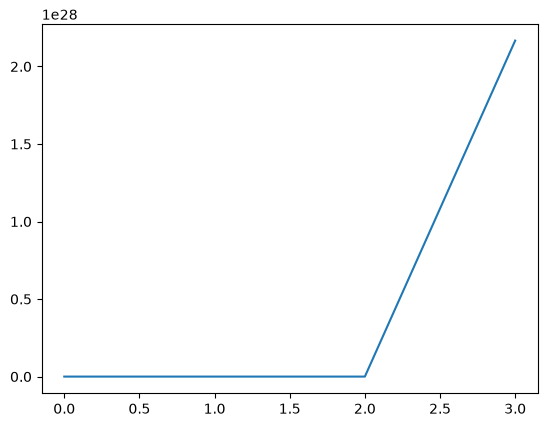

In [19]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import torch
import matplotlib.pyplot as plt
auto_mpg = fetch_ucirepo(id=9)
X = auto_mpg.data.features
y = auto_mpg.data.targets
df = pd.DataFrame(X)
target = pd.DataFrame(y)
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())
displacement = torch.tensor(df["displacement"].values, dtype=torch.float32)
cylinders = torch.tensor(df["cylinders"].values, dtype=torch.float32)
horsepower = torch.tensor(df["horsepower"].values, dtype = torch.float32)
weight = torch.tensor(df["weight"].values, dtype=torch.float32)
acceleration = torch.tensor(df["acceleration"].values, dtype=torch.float32)
Y = torch.tensor(target["mpg"].values, dtype = torch.float32)
w1 = torch.tensor(0.0, requires_grad=True)
w2 = torch.tensor(0.0, requires_grad=True)
w3 = torch.tensor(0.0, requires_grad=True)
w4 = torch.tensor(0.0, requires_grad=True)
w5 = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
epochs = 1000
learning_rate = 0.001
loss_plot = []
for i in range(epochs):
    y_pred = displacement*w1 + cylinders*w2 + horsepower*w3 + weight*w4 + acceleration*w5 + b
    
    loss = ((y_pred-Y)**2).mean()
    
    loss_plot.append(loss.item())
    loss.backward()
    
    with torch.no_grad():
        w1 -= learning_rate*w1.grad
        w2 -= learning_rate*w2.grad
        w3 -= learning_rate*w3.grad
        w4 -= learning_rate*w4.grad
        w5 -= learning_rate*w5.grad
        b -= learning_rate*b.grad
    
    w1.grad = None
    w2.grad = None
    w3.grad = None
    w4.grad = None
    w5.grad = None
    b.grad = None


plt.plot(loss_plot)
plt.show()


In [11]:
df.isnull().sum()

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64